In [6]:
# ============================================================
# Cell 1: Import Libraries
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2


In [7]:
# ============================================================
# Cell 2: Configuration
# ============================================================

# Mixed Precision
mixed_precision.set_global_policy("mixed_float16")

# Random Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Image Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Model Configuration
NUM_CLASSES = 3
INITIAL_EPOCHS = 20
FINE_TUNE_EPOCHS = 10

# Learning Rate
LEARNING_RATE = 1e-4
FINE_TUNE_LR = 1e-5

# Dataset Pipeline
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration Loaded Successfully")
print("Mixed Precision:", mixed_precision.global_policy())

Configuration Loaded Successfully
Mixed Precision: <DTypePolicy "mixed_float16">


In [8]:
# ============================================================
# Cell 3: Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# ============================================================
# Cell 4: Dataset Paths
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/Research paper/dataset of pneomunia/processed_dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train Exists :", os.path.exists(TRAIN_DIR))
print("Val Exists   :", os.path.exists(VAL_DIR))
print("Test Exists  :", os.path.exists(TEST_DIR))

Train Exists : True
Val Exists   : True
Test Exists  : True


In [10]:
# ============================================================
# Cell 5: Load Dataset
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Save class names BEFORE optimization
CLASS_NAMES = train_ds.class_names

print("\nClasses:", CLASS_NAMES)
print("Number of Classes:", len(CLASS_NAMES))

Found 4099 files belonging to 3 classes.
Found 878 files belonging to 3 classes.
Found 879 files belonging to 3 classes.

Classes: ['BACTERIA', 'NORMAL', 'VIRUS']
Number of Classes: 3


In [11]:
# ============================================================
# Cell 6: Optimize Dataset Pipeline
# ============================================================

train_ds = (
    train_ds
    .cache()
    .shuffle(1000, seed=SEED)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .cache()
    .prefetch(AUTOTUNE)
)

print("✅ Dataset Pipeline Optimized")

✅ Dataset Pipeline Optimized


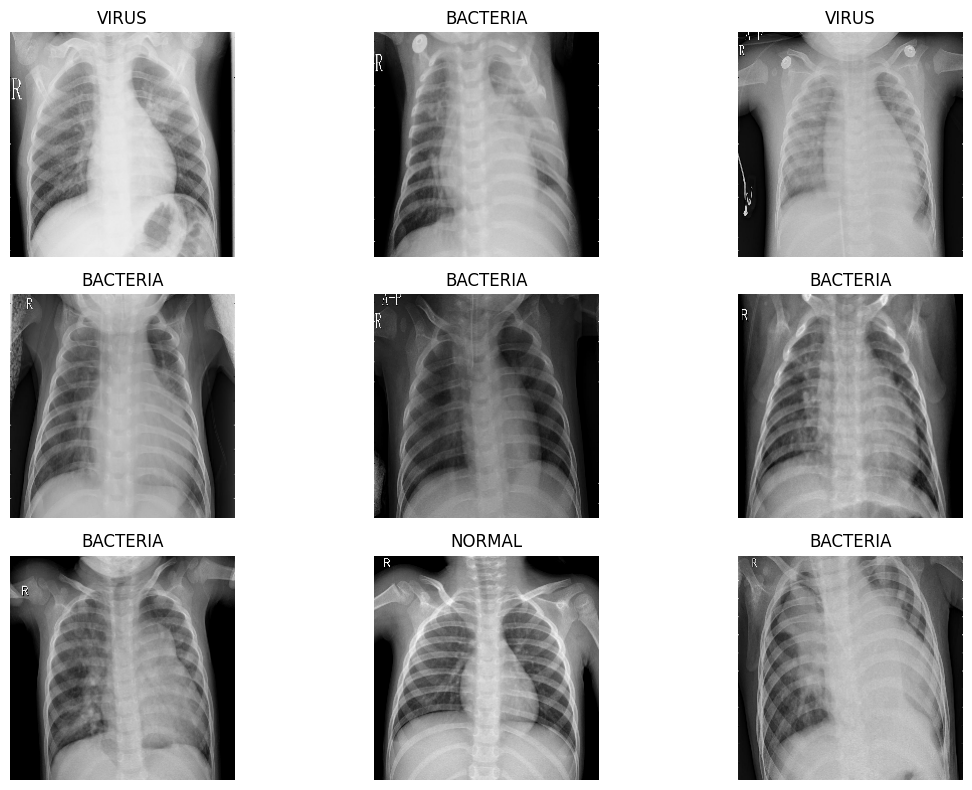

In [12]:
# ============================================================
# Cell 7: Visualize Sample Images
# ============================================================

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(CLASS_NAMES[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Cell 8: Compute Class Weights
# ============================================================

labels = np.concatenate(
    [y.numpy() for _, y in train_ds],
    axis=0
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    i: float(w)
    for i, w in enumerate(weights)
}

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 0.7021240150736554, 1: 1.233152827918171, 2: 1.3074960127591706}


In [14]:
# ============================================================
# Cell 9: Data Augmentation
# ============================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
])

print(data_augmentation)

<Sequential name=sequential, built=False>


In [22]:
# ============================================================
# Cell 10: Build EfficientNetB0 Model
# ============================================================

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

# Data Augmentation
x = data_augmentation(inputs)

# EfficientNet Preprocessing
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Feature Extraction
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="predictions"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_Pneumonia"
)

print("✅ Model Built Successfully")
model.summary()

✅ Model Built Successfully


Model: "EfficientNetB0_Pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,534 (15.48 MB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [23]:
# ============================================================
# Cell 11: Compile Model
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [24]:
# ============================================================
# Cell 12: Training Callbacks
# ============================================================

os.makedirs("models", exist_ok=True)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "models/best_efficientnetb0.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    early_stopping,
    checkpoint,
    reduce_lr
]

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [25]:
# ============================================================
# Cell 13: Initial Training
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("✅ Initial Training Completed")

Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4342 - loss: 1.4586
Epoch 1: val_accuracy improved from None to 0.60706, saving model to models/best_efficientnetb0.keras

Epoch 1: finished saving model to models/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 32s 128ms/step - accuracy: 0.4784 - loss: 1.3206 - val_accuracy: 0.6071 - val_loss: 0.8993 - learning_rate: 1.0000e-04
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5664 - loss: 1.0475
Epoch 2: val_accuracy improved from 0.60706 to 0.64237, saving model to models/best_efficientnetb0.keras

Epoch 2: finished saving model to models/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.5894 - loss: 1.0009 - val_accuracy: 0.6424 - val_loss: 0.8254 - learning_rate: 1.0000e-04
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6153 - loss: 0.9616
Epoch 3: val_accuracy improved from 0.64237 to 0.65604, saving model to models/best_efficientnetb0.ke

In [20]:
import os

print(os.path.exists("models/best_efficientnetb0.keras"))

True


In [21]:
# ============================================================
# Cell 14: Evaluate Model
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "=" * 40)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print("=" * 40)

28/28 ━━━━━━━━━━━━━━━━━━━━ 332s 12s/step - accuracy: 0.6962 - loss: 0.7140

Test Loss     : 0.7140
Test Accuracy : 0.6962


In [26]:
# ============================================================
# Cell 14: Fine-Tuning
# ============================================================

# Unfreeze the last layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=history.epoch[-1] + 1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("✅ Fine-Tuning Completed")

Epoch 21/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6186 - loss: 0.8393
Epoch 21: val_accuracy did not improve from 0.67995
129/129 ━━━━━━━━━━━━━━━━━━━━ 59s 203ms/step - accuracy: 0.6382 - loss: 0.8316 - val_accuracy: 0.6173 - val_loss: 0.9110 - learning_rate: 1.0000e-05
Epoch 22/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6824 - loss: 0.7449
Epoch 22: val_accuracy did not improve from 0.67995
129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.6782 - loss: 0.7300 - val_accuracy: 0.6731 - val_loss: 0.7930 - learning_rate: 1.0000e-05
Epoch 23/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6964 - loss: 0.7203
Epoch 23: val_accuracy did not improve from 0.67995

Epoch 23: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.6924 - loss: 0.7126 - val_accuracy: 0.6697 - val_loss: 0.7725 - learning_rate: 1.0000e-05
Epoch 24/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - ac

In [27]:
# ============================================================
# Cell 15: Final Evaluation
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print("=" * 50)

# Save final model
model.save("models/final_efficientnetb0.keras")

print("✅ Final Model Saved")

28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.5859 - loss: 1.0106
Test Loss     : 1.0106
Test Accuracy : 0.5859
✅ Final Model Saved
